# 06. Regression Evaluation and Nonlinear Fitting
@Shengli (Bruce) Jiang, University of South Carolina

This notebook extends the linear-regression workflow to model evaluation, gradient descent, and nonlinear least-squares fitting.

1. Separate training and test data
2. Compare common regression metrics
3. Implement gradient descent
4. Fit a nonlinear exponential model
5. Estimate polymer stress-relaxation parameters


## Running the notebook

Run cells from top to bottom. A later cell may depend on a variable created earlier. When finished, restart the kernel and run all cells to confirm that the notebook is reproducible.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.optimize import curve_fit


## 1. Separate Training and Test Data

The model learns its parameters from the training set. The test set is held back and used to evaluate predictions on data that were not used during fitting.


### 1.1 Build a small dataset

`np.arange(10)` creates the integers from 0 through 9. Reshaping gives five samples with two features per sample. The target vector contains one value for each row of $X$.


In [2]:
X = np.arange(10).reshape((5, 2))
y = np.arange(5)

print(X)
print(y)
print("X shape =", X.shape)
print("y shape =", y.shape)


[[0 1]
 [2 3]
 [4 5]
 [6 7]
 [8 9]]
[0 1 2 3 4]
X shape = (5, 2)
y shape = (5,)


### 1.2 Make a reproducible random split

`test_size=0.2` assigns one of the five samples to the test set. The same permutation is applied to $X$ and $y$, so each feature row remains paired with its target.


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=26,
    shuffle=True,
)

print("X_train\n", X_train)
print("X_test\n", X_test)
print("y_train", y_train)
print("y_test", y_test)


X_train
 [[6 7]
 [4 5]
 [2 3]
 [0 1]]
X_test
 [[8 9]]
y_train [3 2 1 0]
y_test [4]


### 1.3 What changes when shuffling is off?

Without shuffling, the original order is preserved. Here, the first four samples become the training set and the final sample becomes the test set. This is useful for time-ordered data, but an ordinary random split is usually preferred when sample order has no meaning.


In [4]:
X_train_ordered, X_test_ordered, y_train_ordered, y_test_ordered = (
    train_test_split(X, y, test_size=0.2, shuffle=False)
)

print("X_train\n", X_train_ordered)
print("X_test\n", X_test_ordered)
print("y_train", y_train_ordered)
print("y_test", y_test_ordered)


X_train
 [[0 1]
 [2 3]
 [4 5]
 [6 7]]
X_test
 [[8 9]]
y_train [0 1 2 3]
y_test [4]


## 2. Regression Metrics

Let $y_i$ be an observed value and $\hat y_i$ its prediction.

$$
\mathrm{MAE}=\frac{1}{n}\sum_{i=1}^{n}|y_i-\hat y_i|,
\qquad
\mathrm{MSE}=\frac{1}{n}\sum_{i=1}^{n}(y_i-\hat y_i)^2,
$$

$$
\mathrm{RMSE}=\sqrt{\mathrm{MSE}},
\qquad
R^2=1-\frac{\sum_i(y_i-\hat y_i)^2}{\sum_i(y_i-\bar y)^2}.
$$

MAE reports a typical absolute error. MSE gives more weight to large errors. RMSE returns the error to the units of the target. $R^2$ compares the model with predicting the sample mean.


### 2.1 Calculate MAE, MSE, RMSE, and $R^2$


In [ ]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0, 2, 8])

mae = mean_absolute_error(y_true, y_pred)
mse = mean_squared_error(y_true, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_true, y_pred)

print("MAE =", mae)
print("MSE =", mse)
print("RMSE =", rmse)
print("R2 =", r2)


MAE = 0.5
MSE = 0.375
RMSE = 0.6123724356957945
R2 = 0.9486081370449679


### 2.2 Why $R^2$ is not enough

A high $R^2$ can occur even when the errors are too large for the application. A low $R^2$ can occur when the target varies over a narrow range, even if the absolute errors are small.


In [ ]:
y_true = [0, 100, 200, 300]
y_pred = [10, 110, 210, 310]

print("R2 =", r2_score(y_true, y_pred))
print("MAE =", mean_absolute_error(y_true, y_pred))


R2 = 0.992
MAE = 10.0


In [ ]:
y_true = [99, 100, 101, 100]
y_pred = [100, 100, 100, 100]

print("R2 =", r2_score(y_true, y_pred))
print("MAE =", mean_absolute_error(y_true, y_pred))


R2 = 0.0
MAE = 0.5


The two examples should be judged differently depending on the allowable error. Report $R^2$ together with an error metric, a residual plot, and results on held-out data.


### 2.3 Mean absolute percentage error

MAPE expresses error relative to the observed value.

$$
\mathrm{MAPE}=\frac{100\%}{n}\sum_{i=1}^{n}\left|\frac{y_i-\hat y_i}{y_i}\right|.
$$

MAPE is most useful when the targets are positive and safely away from zero. A zero or very small target makes the percentage undefined or extremely large.


In [8]:
y_percent_true = np.array([100, 200, 300, 400])
y_percent_pred = np.array([110, 190, 330, 360])

mape = 100 * np.mean(
    np.abs((y_percent_true - y_percent_pred) / y_percent_true)
)

print("MAPE (%) =", mape)


MAPE (%) = 8.75


### 2.4 Inspect the residuals

The residual is defined here as $e_i=y_i-\hat y_i$. A useful residual plot is centered around zero without a clear curve, funnel shape, or other systematic pattern.


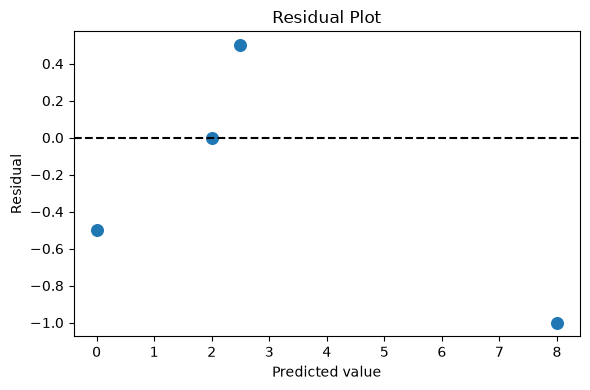

In [9]:
y_true = np.array([3, -0.5, 2, 7])
y_pred = np.array([2.5, 0, 2, 8])

residuals = y_true - y_pred

fig, ax = plt.subplots(figsize=(6, 4))

ax.scatter(y_pred, residuals, s=70)
ax.axhline(y=0, color="black", linestyle="--")

ax.set_xlabel("Predicted value")
ax.set_ylabel("Residual")
ax.set_title("Residual Plot")

fig.tight_layout()
plt.show()

## 3. Gradient Descent for Least Squares

For the linear model $\hat y=X\theta$, use the squared-error loss

$$
J(\theta)=\frac{1}{2n}\|X\theta-y\|_2^2.
$$

Gradient descent repeats two calculations:

$$
\nabla_\theta J=\frac{1}{n}X^T(X\theta-y),
\qquad
\theta^{(k+1)}=\theta^{(k)}-\eta\nabla_\theta J.
$$

The learning rate $\eta$ controls the step size.


### 3.1 Implement batch gradient descent


In [10]:
def gradient_descent(
    X,
    y,
    theta_initial,
    learning_rate=0.1,
    n_iterations=10,
):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)
    theta = np.asarray(theta_initial, dtype=float).copy()

    theta_history = [theta.copy()]
    y_pred = X @ theta
    loss_history = [0.5 * np.mean((y_pred - y) ** 2)]

    for _ in range(n_iterations):
        y_pred = X @ theta
        residuals = y_pred - y
        gradient = X.T @ residuals / len(y)
        theta = theta - learning_rate * gradient

        theta_history.append(theta.copy())
        y_pred = X @ theta
        loss_history.append(0.5 * np.mean((y_pred - y) ** 2))

    return theta, np.array(theta_history), np.array(loss_history)


### 3.2 Follow one small example

For $X=[1,2]^T$, $y=[2,4]^T$, and $\theta^{(0)}=0$, the first gradient is $-5$. With $\eta=0.1$, the first update gives $\theta^{(1)}=0.5$.


In [11]:
X = np.array([[1], [2]])
y = np.array([2, 4])
theta_initial = np.array([0])

theta, theta_history, loss_history = gradient_descent(
    X,
    y,
    theta_initial,
    learning_rate=0.1,
    n_iterations=10,
)

print("Initial theta", theta_history[0])
print("Theta after one step", theta_history[1])
print("Initial loss", loss_history[0])
print("Loss after one step", loss_history[1])
print("Final theta", theta)


Initial theta [0.]
Theta after one step [0.5]
Initial loss 5.0
Loss after one step 2.8125
Final theta [1.88737297]


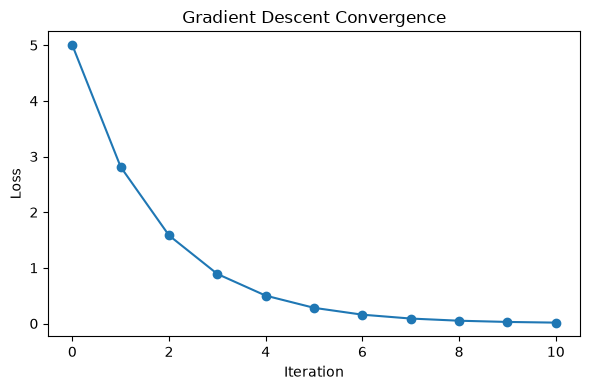

In [12]:
fig, ax = plt.subplots(figsize=(6, 4))

iterations = np.arange(len(loss_history))

ax.plot(iterations, loss_history, marker="o")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Gradient Descent Convergence")

fig.tight_layout()
plt.show()

### 3.3 Impact of the learning rate

A small learning rate produces slow progress. A suitable learning rate reduces the loss efficiently. A learning rate that is too large overshoots the minimum and may cause divergence.


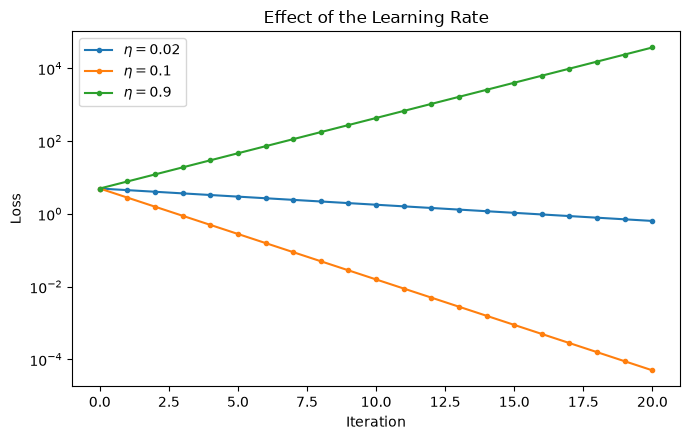

In [13]:
learning_rates = [0.02, 0.10, 0.90]

fig, ax = plt.subplots(figsize=(7, 4.5))

for learning_rate in learning_rates:
    _, _, loss_history = gradient_descent(
        X,
        y,
        theta_initial,
        learning_rate=learning_rate,
        n_iterations=20,
    )

    ax.plot(
        loss_history,
        marker="o",
        markersize=3,
        label=fr"$\eta={learning_rate}$",
    )

ax.set_yscale("log")
ax.set_xlabel("Iteration")
ax.set_ylabel("Loss")
ax.set_title("Effect of the Learning Rate")
ax.legend()

fig.tight_layout()
plt.show()

## 4. Nonlinear Fitting with SciPy

Consider the three-parameter exponential model

$$
f(x;\theta)=a\exp(-bx)+c,
\qquad
\theta=[a,b,c]^T.
$$

The parameter $b$ appears inside the exponential, so this is nonlinear least squares. `curve_fit` estimates the parameters by minimizing the sum of squared residuals.


### 4.1 Generate noisy data


In [14]:
def func(x, a, b, c):
    return a * np.exp(-b * x) + c


X = np.linspace(0, 4, 50)
y_clean = func(X, 2.5, 1.3, 0.5)

rng = np.random.default_rng(26)
y = y_clean + 0.2 * rng.normal(size=X.size)


### 4.2 Fit the parameters

`popt` contains the fitted parameter values. `pcov` is the estimated covariance matrix of those parameters.


In [15]:
popt, pcov = curve_fit(func, X, y)

print("True parameters", np.array([2.5, 1.3, 0.5]))
print("Fitted parameters", popt)


True parameters [2.5 1.3 0.5]
Fitted parameters [2.38353999 1.15045256 0.46503279]


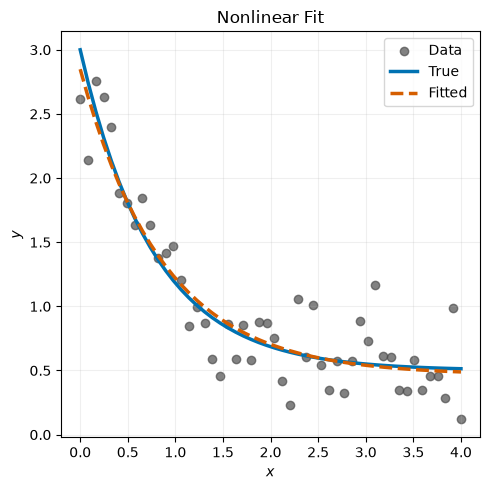

In [16]:
y_true = func(X, 2.5, 1.3, 0.5)

fig, ax = plt.subplots(figsize=(5, 5))

ax.scatter(X, y, color="#4D4D4D", alpha=0.7, label="Data")

ax.plot(X, y_true, color="#0072B2", lw=2.5, label="True")

ax.plot(X, func(X, *popt), "--", color="#D55E00", lw=2.5, label="Fitted")

ax.set(xlabel="$x$", ylabel="$y$", title="Nonlinear Fit")

ax.legend()

ax.grid(alpha=0.2)

fig.tight_layout()

plt.show()

## 5. Polymer Stress Relaxation

When a polymer is suddenly deformed and held at constant strain, its stress decreases as the molecular chains reorganize. For a single fully relaxing mode, the relaxation modulus is

$$
\widehat G(t;\theta)=G_0\exp\left(-\frac{t}{\tau}\right),
\qquad
\theta=[G_0,\tau]^T.
$$

$G_0$ is the initial relaxation modulus and $\tau$ is the characteristic relaxation time. At $t=\tau$, the modulus has fallen to $G_0/e\approx0.37G_0$.

This model approaches zero at long times. A polymer solid with a nonzero equilibrium modulus requires an additional $G_\infty$ term.


### 5.1 Fit the model with gradient descent

For the squared-error loss, the required model derivatives are

$$
\frac{\partial \widehat G}{\partial G_0}
=\exp\left(-\frac{t}{\tau}\right),
\qquad
\frac{\partial \widehat G}{\partial \tau}
=G_0\exp\left(-\frac{t}{\tau}\right)\frac{t}{\tau^2}.
$$

The example starts from positive parameter values and uses a moderate learning rate.


In [17]:
def maxwell_model(t, theta):
    G0, tau = theta
    return G0 * np.exp(-t / tau)


def fit_maxwell_gradient_descent(
    t,
    G,
    theta_initial,
    learning_rate=0.1,
    n_iterations=1000,
):
    theta = np.asarray(theta_initial, dtype=float).copy()
    theta_history = [theta.copy()]
    loss_history = []

    for _ in range(n_iterations):
        G0, tau = theta
        exponential = np.exp(-t / tau)
        G_pred = G0 * exponential
        residuals = G_pred - G

        loss_history.append(0.5 * np.mean(residuals**2))

        dG_dG0 = exponential
        dG_dtau = G0 * exponential * t / tau**2
        gradient = np.array([
            np.mean(residuals * dG_dG0),
            np.mean(residuals * dG_dtau),
        ])

        theta = theta - learning_rate * gradient
        theta_history.append(theta.copy())

    return theta, np.array(theta_history), np.array(loss_history)


In [18]:
rng = np.random.default_rng(7)
t = np.linspace(0, 5, 21)

G0_true = 10.0
tau_true = 1.5
G_true = G0_true * np.exp(-t / tau_true)
G_simulation = G_true + rng.normal(0, 0.15, size=t.size)

theta_initial = np.array([8.0, 2.5])
theta_fit, theta_history, loss_history = fit_maxwell_gradient_descent(
    t,
    G_simulation,
    theta_initial,
    learning_rate=0.1,
    n_iterations=1000,
)

print("True G0", G0_true)
print("Fitted G0", theta_fit[0])
print("True tau", tau_true)
print("Fitted tau", theta_fit[1])


True G0 10.0
Fitted G0 10.022230306201063
True tau 1.5
Fitted tau 1.4739744072890693


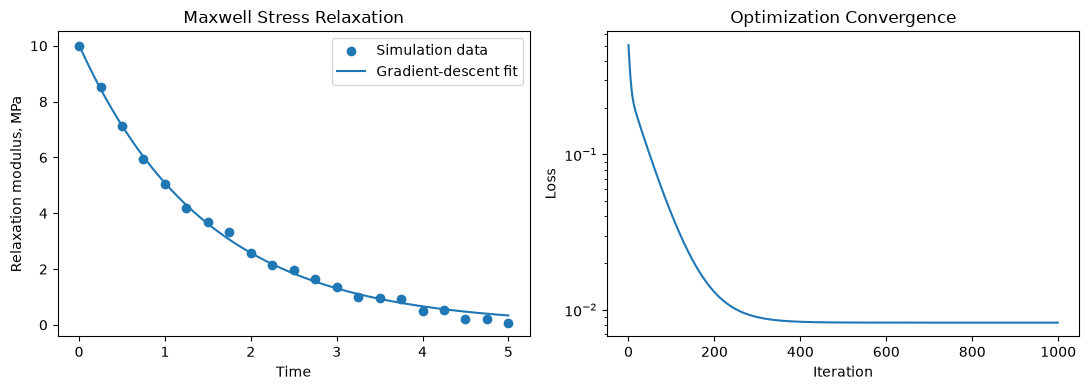

In [19]:
t_plot = np.linspace(t.min(), t.max(), 200)
G_fit = maxwell_model(t_plot, theta_fit)

fig, ax = plt.subplots(
    1,
    2,
    figsize=(11, 4),
)

ax[0].scatter(
    t,
    G_simulation,
    label="Simulation data",
)

ax[0].plot(
    t_plot,
    G_fit,
    label="Gradient-descent fit",
)

ax[0].set_xlabel("Time")
ax[0].set_ylabel("Relaxation modulus, MPa")
ax[0].set_title("Maxwell Stress Relaxation")
ax[0].legend()

ax[1].plot(loss_history)

ax[1].set_xlabel("Iteration")
ax[1].set_ylabel("Loss")
ax[1].set_yscale("log")
ax[1].set_title("Optimization Convergence")

fig.tight_layout()
plt.show()

### 5.2 Compare with `curve_fit`

The lower and upper bounds keep both physical parameters positive. The diagonal of the covariance matrix gives approximate parameter variances under the assumptions used by `curve_fit`.


In [20]:
def maxwell_curve(t, G0, tau):
    return G0 * np.exp(-t / tau)


theta_curve_fit, covariance = curve_fit(
    maxwell_curve,
    t,
    G_simulation,
    p0=theta_initial,
    bounds=(0, np.inf),
)

parameter_error = np.sqrt(np.diag(covariance))

print("G0", theta_curve_fit[0])
print("tau", theta_curve_fit[1])
print("G0 standard error", parameter_error[0])
print("tau standard error", parameter_error[1])


G0 10.022390885765963
tau 1.4739500453574912
G0 standard error 0.0954923457837141
tau standard error 0.021896329137659626


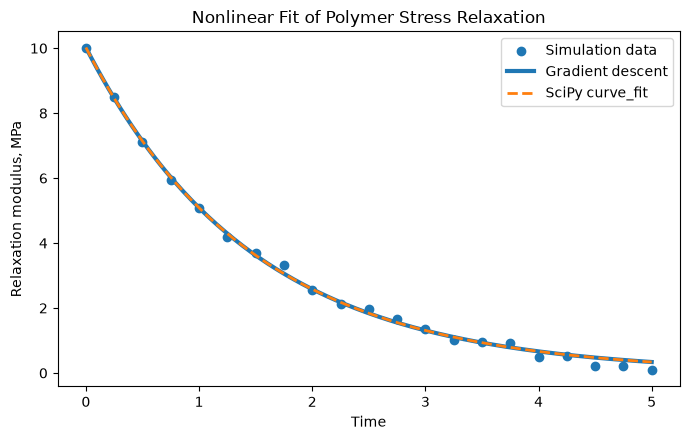

In [21]:
t_plot = np.linspace(t.min(), t.max(), 200)

G_gradient_descent = maxwell_model(
    t_plot,
    theta_fit,
)

G_scipy = maxwell_curve(
    t_plot,
    *theta_curve_fit,
)

fig, ax = plt.subplots(figsize=(7, 4.5))

ax.scatter(
    t,
    G_simulation,
    label="Simulation data",
)

ax.plot(
    t_plot,
    G_gradient_descent,
    linewidth=3,
    label="Gradient descent",
)

ax.plot(
    t_plot,
    G_scipy,
    linestyle="--",
    linewidth=2,
    label="SciPy curve_fit",
)

ax.set_xlabel("Time")
ax.set_ylabel("Relaxation modulus, MPa")
ax.set_title("Nonlinear Fit of Polymer Stress Relaxation")
ax.legend()

fig.tight_layout()
plt.show()